In [421]:
import pandas as pd
from datasets import load_dataset, concatenate_datasets
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import numpy as np
import json
from sklearn.feature_extraction.text import CountVectorizer
#from google.colab import userdata
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon
from tqdm import tqdm
from dotenv import load_dotenv
import os
from sentence_transformers import SentenceTransformer
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
load_dotenv()

# Get the HF token
hf_token = os.getenv('HF_TOKEN')
#print(hf_token)
#HF_Token = userdata.get("HF_Token")
login(token=hf_token)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
model_name="Qwen/Qwen3-4B"

tokenizer=AutoTokenizer.from_pretrained(model_name,trust_remote_code=True, device_map='auto')
model=AutoModelForCausalLM.from_pretrained(model_name,trust_remote_code=True, device_map="auto")

ValueError: Using a `device_map`, `tp_plan`, `torch.device` context manager or setting `torch.set_default_device(device)` requires `accelerate`. You can install it with `pip install accelerate`

## Loading the Databricks Dolly Dataset with approximately 120 prompts with 15 from each category.

In [422]:
dataset=load_dataset("databricks/databricks-dolly-15k",split="train")
dataset = dataset.map(lambda x: {"length": len(x["response"])})
l_dataset=dataset.filter(lambda x: x["length"] > 1000)
categories=['brainstorming', "closed_qa", 'summarization',"creative_writing", 'information_extraction', "general_qa", "classification", 'open_qa']
selected_subsets=[]
for category in categories:
    subset = l_dataset.filter(lambda x: x["category"] == category)
    sampled_subset=subset.select(range(min(15, len(subset))))
    selected_subsets.append(sampled_subset)
data=concatenate_datasets(selected_subsets)
print(len(data))

120


In [423]:
with open("model_responses_500_tokens_trained.json", "r", encoding="utf-8") as f:
    base_model_responses = json.load(f)
data = data.add_column("base_responses", base_model_responses)
data = data.map(lambda x: {"base_length": len(x["base_responses"])})

with open("model_responses_500_tokens_instruct.json", "r", encoding="utf-8") as f:
    instruct_model_responses = json.load(f)
data = data.add_column("instruct_responses", instruct_model_responses)
data = data.map(lambda x: {"instruct_length": len(x["instruct_responses"])})

with open("model_responses_1000_tokens_reasoning.json", "r", encoding="utf-8") as f:
    reasoning_model_responses = json.load(f)
reasoning_res=[res[0] for res in reasoning_model_responses]
thinking_trace=[res[1] for res in reasoning_model_responses]
data = data.add_column("reasoning_responses", reasoning_res)
data = data.add_column("reasoning_thinking", thinking_trace)
data = data.map(lambda x: {"reasoning_length": len(x["reasoning_responses"])})
data = data.map(lambda x: {"reasoning_thinking_length": len(x["reasoning_thinking"])})

In [424]:
data

Dataset({
    features: ['instruction', 'context', 'response', 'category', 'length', 'base_responses', 'base_length', 'instruct_responses', 'instruct_length', 'reasoning_responses', 'reasoning_thinking', 'reasoning_length', 'reasoning_thinking_length'],
    num_rows: 120
})

In [425]:
df=pd.DataFrame(data)

In [426]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   instruction                120 non-null    object
 1   context                    120 non-null    object
 2   response                   120 non-null    object
 3   category                   120 non-null    object
 4   length                     120 non-null    int64 
 5   base_responses             120 non-null    object
 6   base_length                120 non-null    int64 
 7   instruct_responses         120 non-null    object
 8   instruct_length            120 non-null    int64 
 9   reasoning_responses        120 non-null    object
 10  reasoning_thinking         120 non-null    object
 11  reasoning_length           120 non-null    int64 
 12  reasoning_thinking_length  120 non-null    int64 
dtypes: int64(5), object(8)
memory usage: 12.3+ KB


In [427]:
df.describe()

,length,base_length,instruct_length,reasoning_length,reasoning_thinking_length
count,120.000000,120.000000,120.000000,120.00000,120.000000
mean,1918.016667,1129.775000,1300.133333,817.05000,3114.808333
std,1147.413144,644.981043,743.898870,786.88678,1037.902380
min,1008.000000,62.000000,14.000000,0.00000,904.000000
25%,1161.000000,568.500000,638.750000,0.00000,2255.500000
50%,1500.000000,1070.000000,1198.000000,627.00000,3053.000000
75%,2282.250000,1624.250000,1947.250000,1428.00000,4045.250000
max,8736.000000,2632.000000,2783.000000,2601.00000,5176.000000


## Function for extracting the n-gram frequencies
Using sklearn Count Vectorizer

In [428]:
def get_freqs(documents, ngram_range, stop_words):
  vectorizer=CountVectorizer(analyzer='word', ngram_range=ngram_range, stop_words=stop_words)
  n_grams=vectorizer.fit_transform(documents)
  counts = np.array(n_grams.sum(axis=0)).flatten()
  total_count = counts.sum()
  n_grams_names = vectorizer.get_feature_names_out()
  freqs = [
        (ngram, count,(count / total_count) * 100)
        for ngram, count in zip(n_grams_names, counts)
    ]

  freqs = sorted(freqs, key=lambda x: x[1], reverse=True)
  return freqs

### We compare responses from three models:
1. Qwen3-4B
2. Qwen3-4B-Instruct-2507
3. Qwen3-4B-Thinking-2507

We also capture the thinking trace of the reasoning model and calculate the n-grams

In [273]:
base_bigrams=get_freqs(data['base_responses'],ngram_range=(2,2),stop_words="english")
base_trigrams=get_freqs(data['base_responses'],ngram_range=(3,3),stop_words="english")
base_fourgrams=get_freqs(data['base_responses'],ngram_range=(4,4),stop_words="english")

instruct_bigrams=get_freqs(data['instruct_responses'],ngram_range=(2,2),stop_words="english")
instruct_trigrams=get_freqs(data['instruct_responses'],ngram_range=(3,3),stop_words="english")
instruct_fourgrams=get_freqs(data['instruct_responses'],ngram_range=(4,4),stop_words="english")

reasoning_bigrams=get_freqs(data['reasoning_responses'],ngram_range=(2,2),stop_words="english")
reasoning_trigrams=get_freqs(data['reasoning_responses'],ngram_range=(3,3),stop_words="english")
reasoning_fourgrams=get_freqs(data['reasoning_responses'],ngram_range=(4,4),stop_words="english")

reasoning_think_bigrams=get_freqs(data['reasoning_thinking'],ngram_range=(2,2),stop_words="english")
reasoning_think_trigrams=get_freqs(data['reasoning_thinking'],ngram_range=(3,3),stop_words="english")
reasoning_think_fourgrams=get_freqs(data['reasoning_thinking'],ngram_range=(4,4),stop_words="english")

human_bigrams=get_freqs(data['response'],ngram_range=(2,2),stop_words="english")
human_trigrams=get_freqs(data['response'],ngram_range=(3,3),stop_words="english")
human_fourgrams=get_freqs(data['response'],ngram_range=(4,4),stop_words="english")

In [429]:
base_bigrams=get_freqs(data['base_responses'],ngram_range=(2,2),stop_words=None)
base_trigrams=get_freqs(data['base_responses'],ngram_range=(3,3),stop_words=None)
base_fourgrams=get_freqs(data['base_responses'],ngram_range=(4,4),stop_words=None)

instruct_bigrams=get_freqs(data['instruct_responses'],ngram_range=(2,2),stop_words=None)
instruct_trigrams=get_freqs(data['instruct_responses'],ngram_range=(3,3),stop_words=None)
instruct_fourgrams=get_freqs(data['instruct_responses'],ngram_range=(4,4),stop_words=None)

reasoning_bigrams=get_freqs(data['reasoning_responses'],ngram_range=(2,2),stop_words=None)
reasoning_trigrams=get_freqs(data['reasoning_responses'],ngram_range=(3,3),stop_words=None)
reasoning_fourgrams=get_freqs(data['reasoning_responses'],ngram_range=(4,4),stop_words=None)

reasoning_think_bigrams=get_freqs(data['reasoning_thinking'],ngram_range=(2,2),stop_words=None)
reasoning_think_trigrams=get_freqs(data['reasoning_thinking'],ngram_range=(3,3),stop_words=None)
reasoning_think_fourgrams=get_freqs(data['reasoning_thinking'],ngram_range=(4,4),stop_words=None)

human_bigrams=get_freqs(data['response'],ngram_range=(2,2),stop_words=None)
human_trigrams=get_freqs(data['response'],ngram_range=(3,3),stop_words=None)
human_fourgrams=get_freqs(data['response'],ngram_range=(4,4),stop_words=None)

In [334]:
custom_stop_words=["context"]

base_bigrams=get_freqs(data['base_responses'],ngram_range=(2,2),stop_words=custom_stop_words)
base_trigrams=get_freqs(data['base_responses'],ngram_range=(3,3),stop_words=custom_stop_words)
base_fourgrams=get_freqs(data['base_responses'],ngram_range=(4,4),stop_words=custom_stop_words)

instruct_bigrams=get_freqs(data['instruct_responses'],ngram_range=(2,2),stop_words=custom_stop_words)
instruct_trigrams=get_freqs(data['instruct_responses'],ngram_range=(3,3),stop_words=custom_stop_words)
instruct_fourgrams=get_freqs(data['instruct_responses'],ngram_range=(4,4),stop_words=custom_stop_words)

reasoning_bigrams=get_freqs(data['reasoning_responses'],ngram_range=(2,2),stop_words=custom_stop_words)
reasoning_trigrams=get_freqs(data['reasoning_responses'],ngram_range=(3,3),stop_words=custom_stop_words)
reasoning_fourgrams=get_freqs(data['reasoning_responses'],ngram_range=(4,4),stop_words=custom_stop_words)

reasoning_think_bigrams=get_freqs(data['reasoning_thinking'],ngram_range=(2,2),stop_words=custom_stop_words)
reasoning_think_trigrams=get_freqs(data['reasoning_thinking'],ngram_range=(3,3),stop_words=custom_stop_words)
reasoning_think_fourgrams=get_freqs(data['reasoning_thinking'],ngram_range=(4,4),stop_words=custom_stop_words)

human_bigrams=get_freqs(data['response'],ngram_range=(2,2),stop_words=custom_stop_words)
human_trigrams=get_freqs(data['response'],ngram_range=(3,3),stop_words=custom_stop_words)
human_fourgrams=get_freqs(data['response'],ngram_range=(4,4),stop_words=custom_stop_words)

In [430]:
bigram_dict = {
    "Human": human_bigrams,
    "Base": base_bigrams,
    "Instruct": instruct_bigrams,
    "Reasoning": reasoning_bigrams,
    "Thinking_Trace": reasoning_think_bigrams
}

trigram_dict = {
    "Human": human_trigrams,
    "Base": base_trigrams,
    "Instruct": instruct_trigrams,
    "Reasoning": reasoning_trigrams,
    "Thinking_Trace": reasoning_think_trigrams
}

fourgram_dict = {
    "Human": human_fourgrams,
    "Base": base_fourgrams,
    "Instruct": instruct_fourgrams,
    "Reasoning": reasoning_fourgrams,
    "Thinking_Trace": reasoning_think_fourgrams
}

ngram_data = {
    2: bigram_dict,
    3: trigram_dict,
    4: fourgram_dict
}

## Helper Functions to create plots

In [431]:
def plot_top_ngrams_grid(ngram_dict, ngram_label, top_k=20):
    """
    ngram_dict format:
    {
        "Human": human_ngrams,
        "Base": base_ngrams,
        "Instruct": instruct_ngrams,
        "Reasoning": reasoning_ngrams
    }

    Each ngram list should contain tuples:
    (ngram, count, percentage)
    """
    #n_plots = len(ngram_dict)
    fig, axes = plt.subplots(3, 2, figsize=(18, 12))
    axes = axes.flatten()

    for ax, (source_name, ngram_list) in zip(axes, ngram_dict.items()):
        top = ngram_list[:top_k]

        temp_df = pd.DataFrame(
            top,
            columns=["ngram", "count", "percentage"]
        )

        # Reverse so the highest value appears at the top
        #temp_df = temp_df.iloc[::-1]

        sns.barplot(data=temp_df, x="percentage", y="ngram", ax=ax, orient="h")
        ax.set_title(f"{source_name} - Top {top_k} {ngram_label}")
        ax.set_xlabel("Percentage of all n-grams")
        ax.set_ylabel("")

    plt.suptitle(f"Top {top_k} {ngram_label} by Source", fontsize=16)
    plt.tight_layout()
    plt.show()

In [432]:
def ngram_list_to_df(ngram_list):
    df = pd.DataFrame(
        ngram_list,
        columns=["ngram", "count", "percentage"]
    )
    df["count"] = df["count"].astype(float)
    df["percentage"] = df["percentage"].astype(float)
    return df

In [433]:
def jaccard_similarity(set_a, set_b):
    if len(set_a | set_b) == 0:
        return 0
    return len(set_a & set_b) / len(set_a | set_b)


def ngram_overlap_matrix(source_dict, top_k=100):
    """
    source_dict example:
    {
        "Human": human_bigrams,
        "Base": base_bigrams,
        ...
    }
    """

    names = list(source_dict.keys())

    top_sets = {}
    for name, ngram_list in source_dict.items():
        df_temp = ngram_list_to_df(ngram_list)
        top_sets[name] = set(df_temp.head(top_k)["ngram"])

    matrix = pd.DataFrame(index=names, columns=names, dtype=float)

    for name1 in names:
        for name2 in names:
            matrix.loc[name1, name2] = jaccard_similarity(
                top_sets[name1],
                top_sets[name2]
            )

    return matrix

In [434]:
def plot_heatmap(matrix, title):
    plt.figure(figsize=(7, 6))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [435]:
def cosine_similarity_from_ngram_lists(list_a, list_b):
    df_a = ngram_list_to_df(list_a)
    df_b = ngram_list_to_df(list_b)

    counts_a = dict(zip(df_a["ngram"], df_a["count"]))
    counts_b = dict(zip(df_b["ngram"], df_b["count"]))

    all_ngrams = sorted(set(counts_a.keys()) | set(counts_b.keys()))

    vec_a = np.array([counts_a.get(ng, 0) for ng in all_ngrams], dtype=float)
    vec_b = np.array([counts_b.get(ng, 0) for ng in all_ngrams], dtype=float)

    if np.linalg.norm(vec_a) == 0 or np.linalg.norm(vec_b) == 0:
        return 0

    return np.dot(vec_a, vec_b) / (np.linalg.norm(vec_a) * np.linalg.norm(vec_b))

In [436]:
def pairwise_cosine_matrix(source_dict):
    names = list(source_dict.keys())
    matrix = pd.DataFrame(index=names, columns=names, dtype=float)

    for name1 in names:
        for name2 in names:
            matrix.loc[name1, name2] = cosine_similarity_from_ngram_lists(
                source_dict[name1],
                source_dict[name2]
            )

    return matrix

### Top 20 2-grams per model

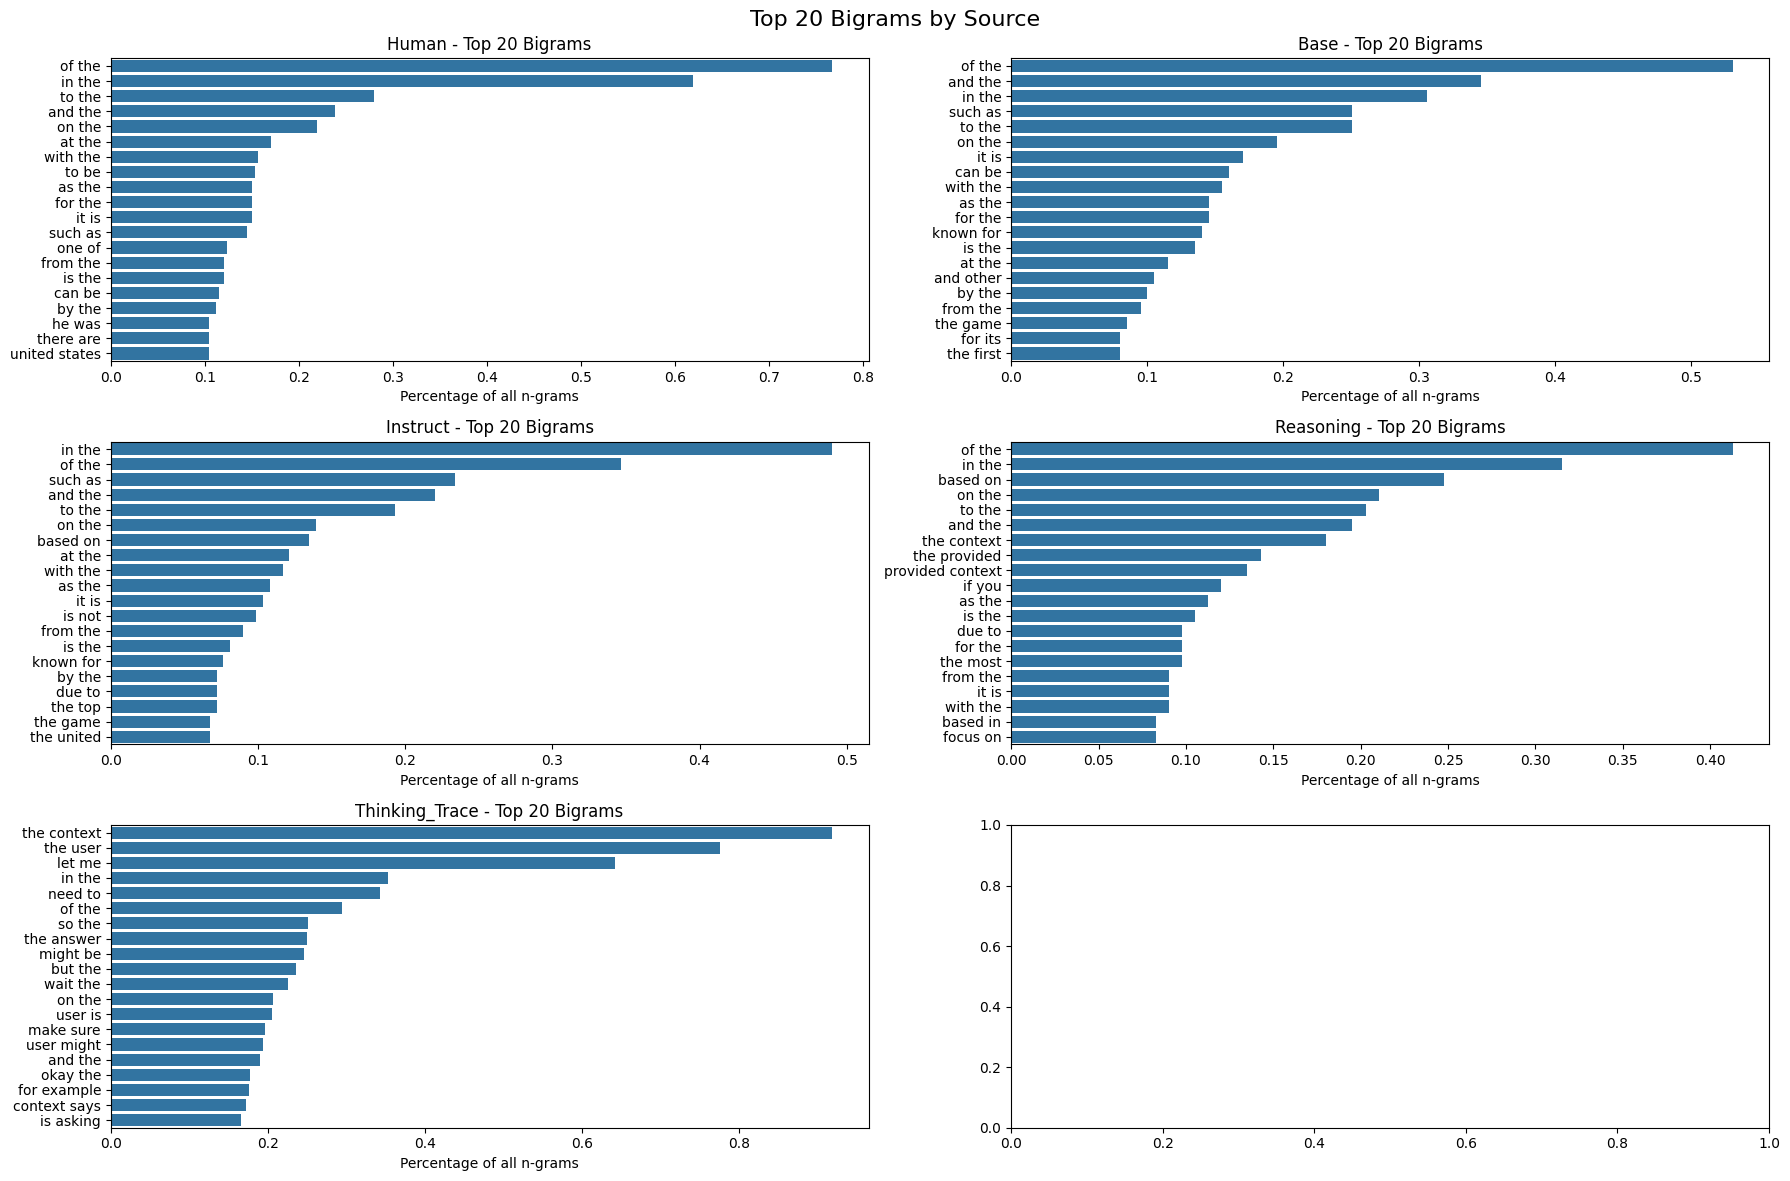

In [437]:
plot_top_ngrams_grid(bigram_dict, "Bigrams", top_k=20)


### Top 20 3-grams per model

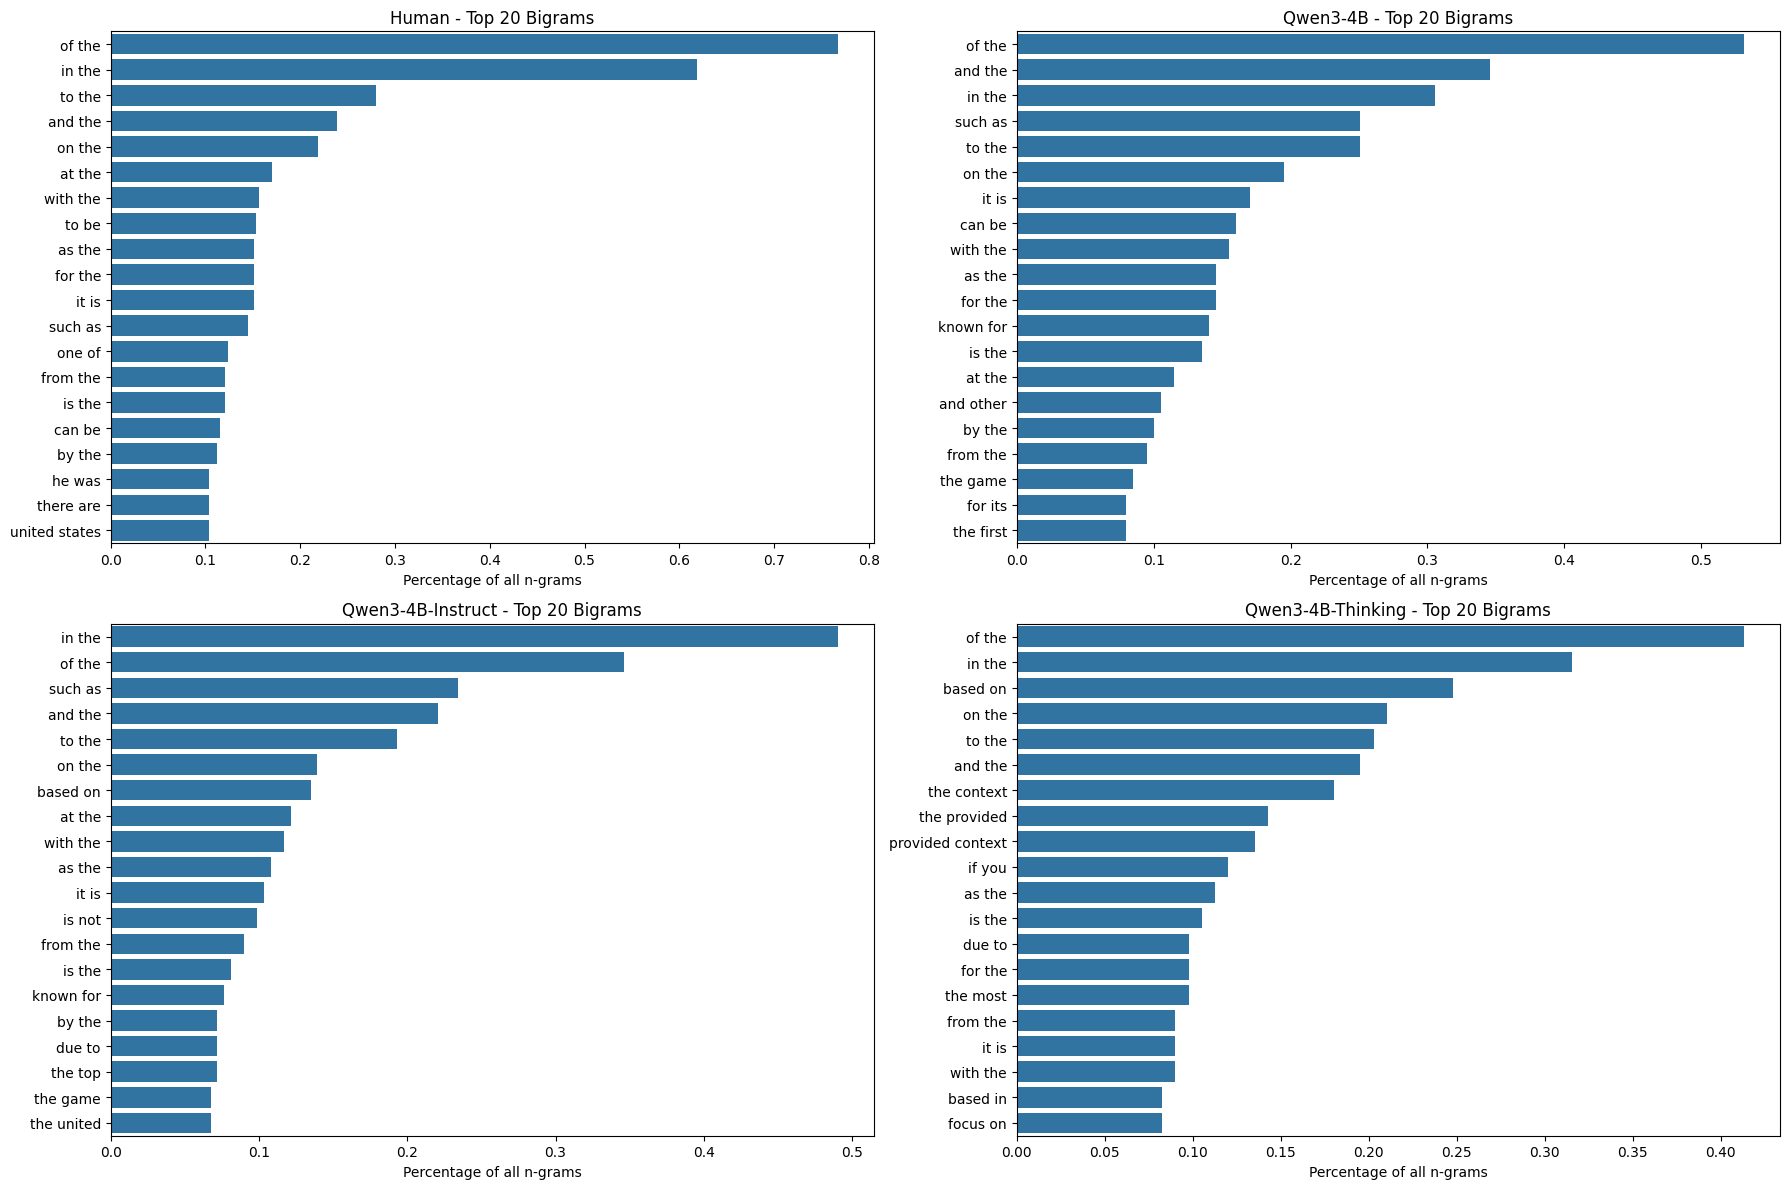

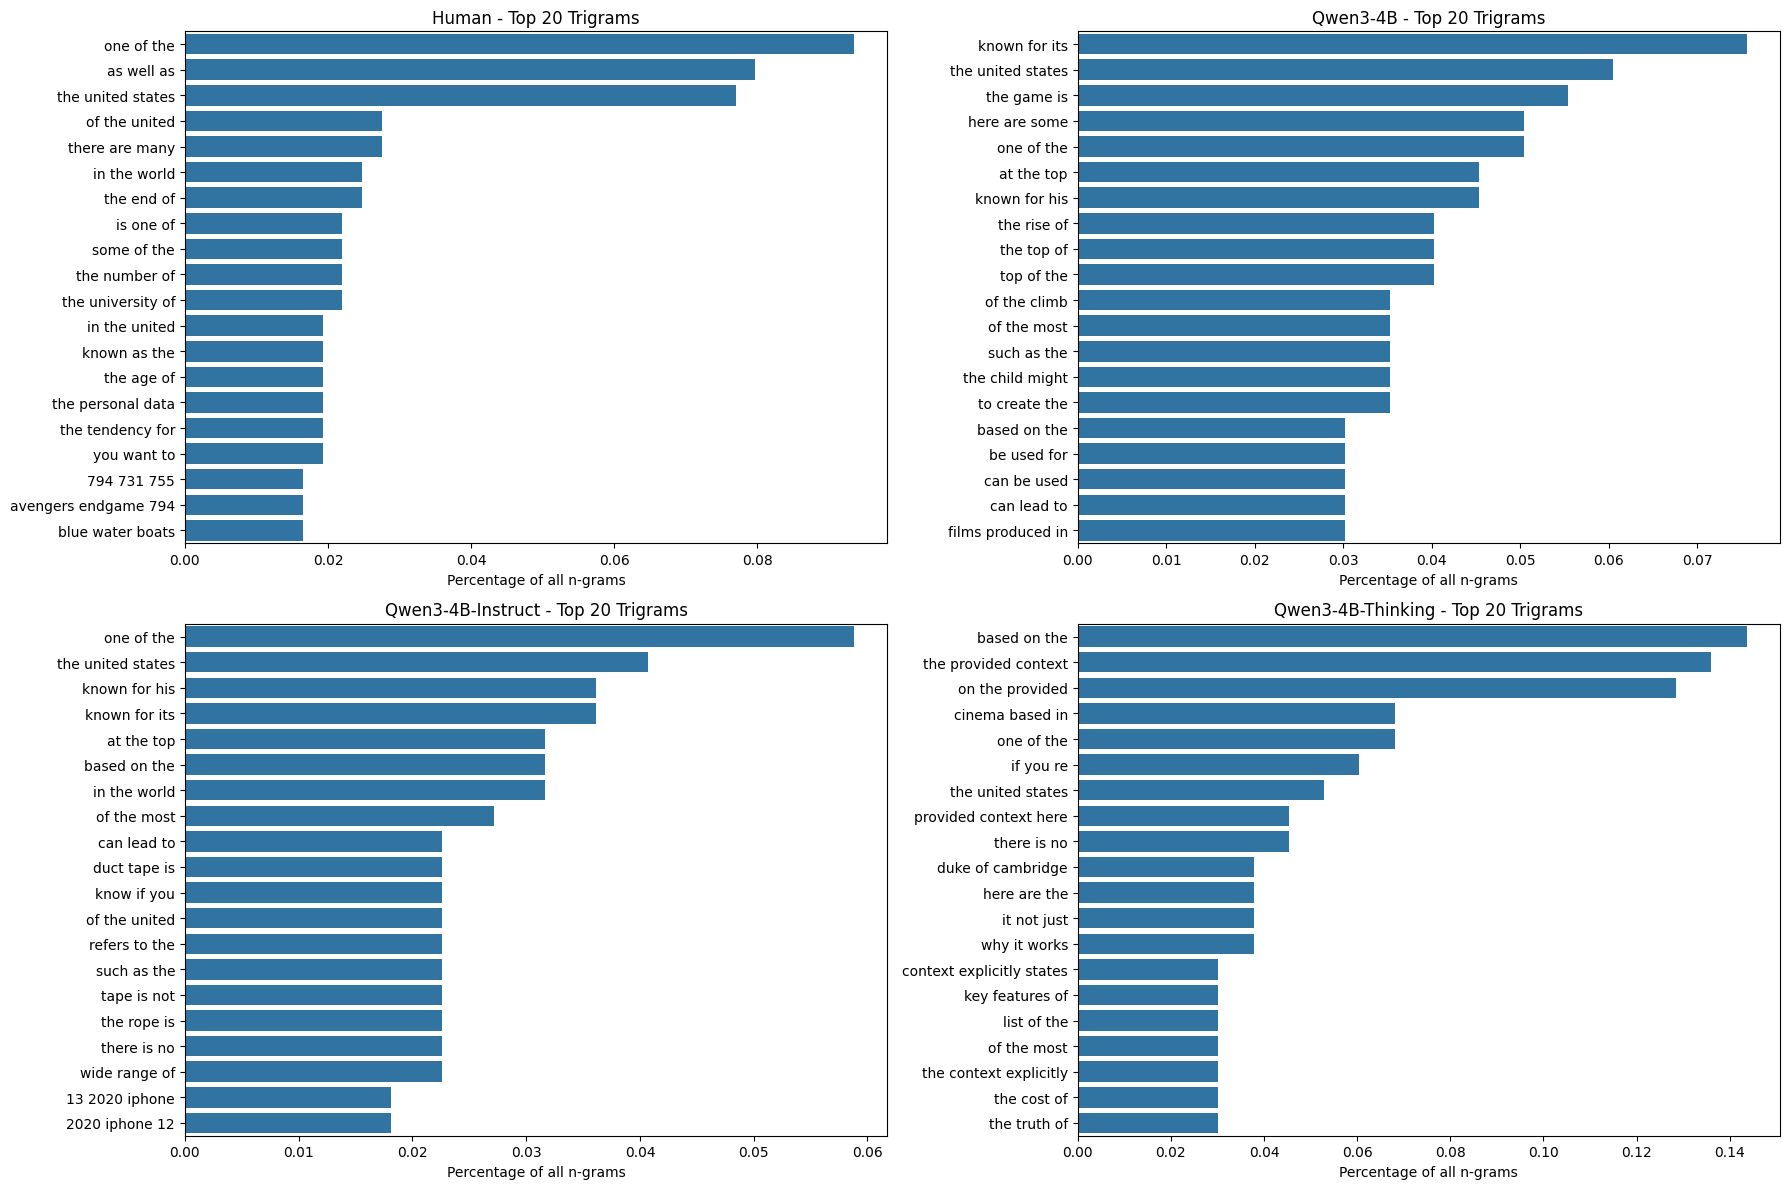

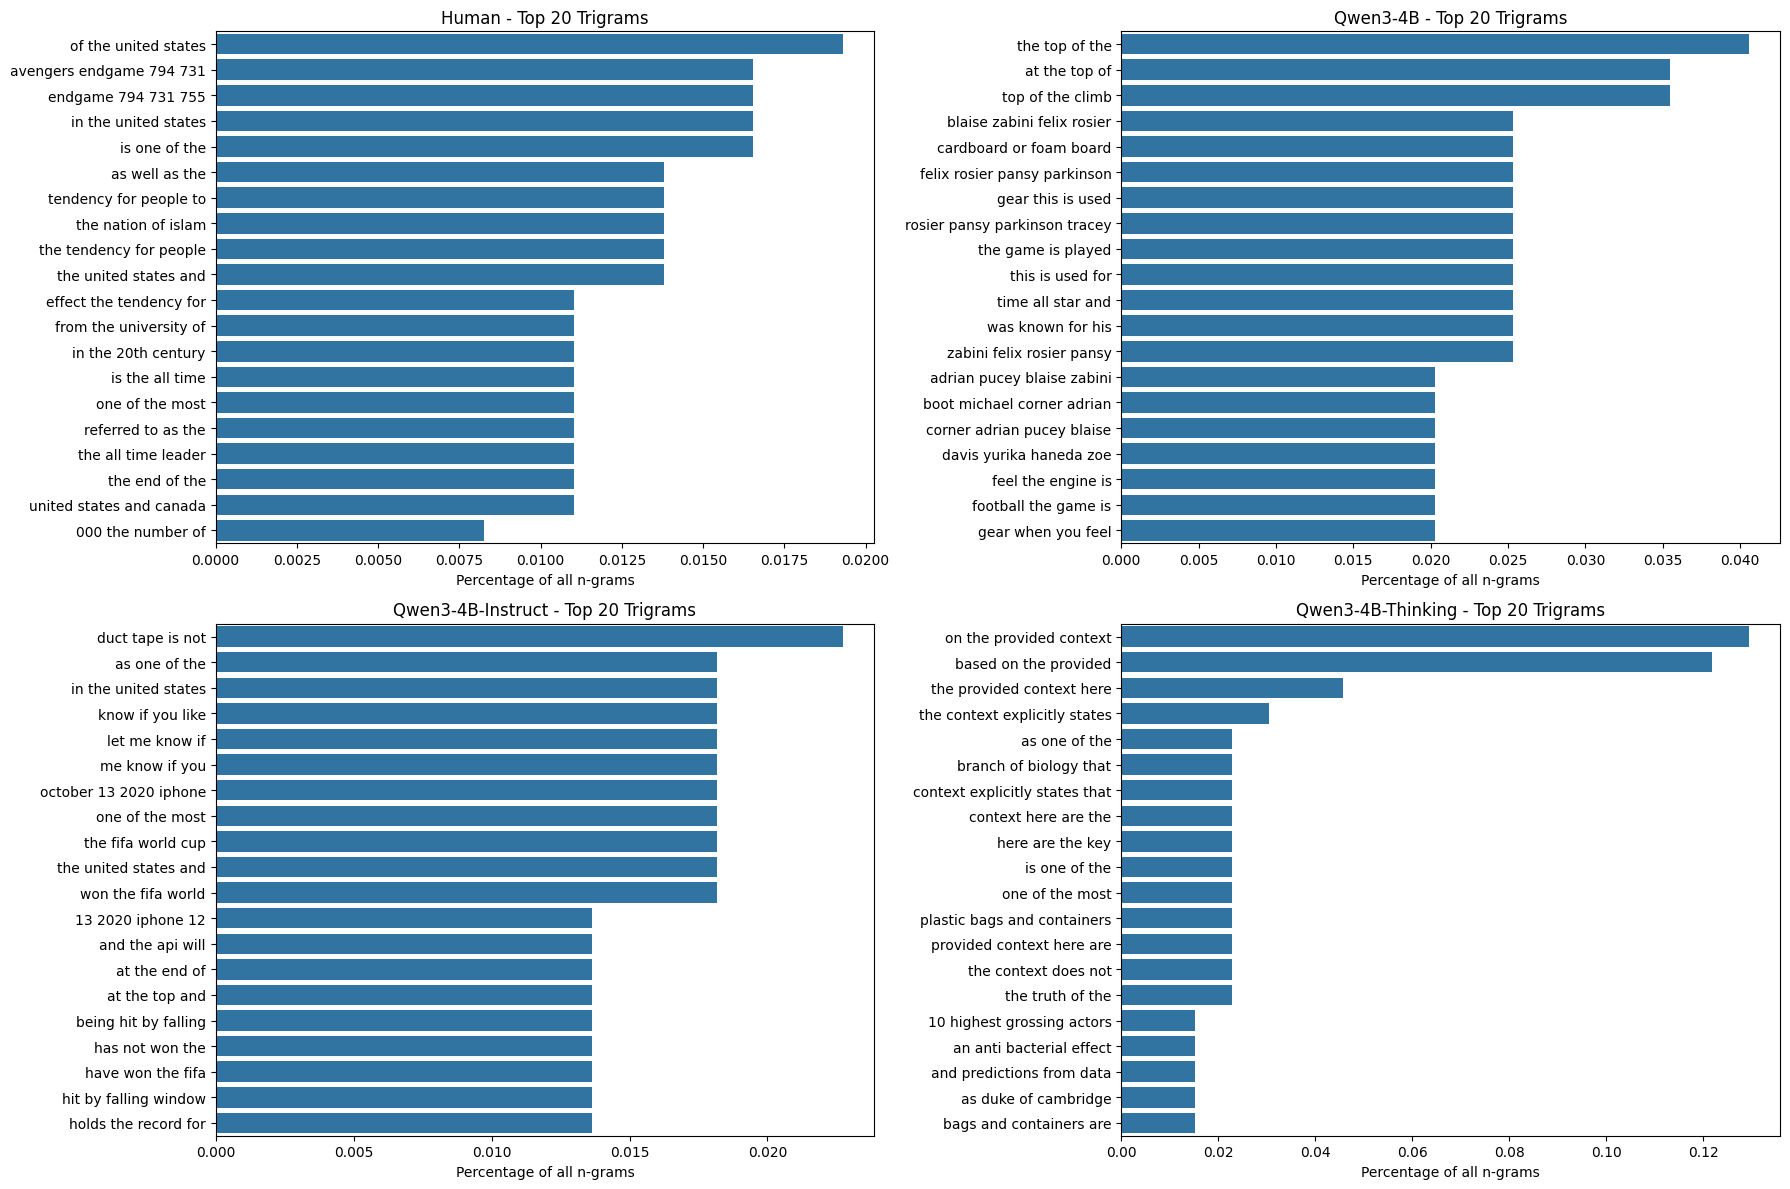

In [438]:
def plot_ngrams_grid(ngram_dict, ngram_label, top_k=20):

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()

    for ax, (source_name, ngram_list) in zip(axes, ngram_dict.items()):
        top = ngram_list[:top_k]

        temp_df = pd.DataFrame(
            top,
            columns=["ngram", "count", "percentage"]
        )

        # Reverse so the highest value appears at the top
        #temp_df = temp_df.iloc[::-1]

        sns.barplot(data=temp_df, x="percentage", y="ngram", ax=ax, orient="h")
        ax.set_title(f"{source_name} - Top {top_k} {ngram_label}")
        ax.set_xlabel("Percentage of all n-grams")
        ax.set_ylabel("")

    #plt.suptitle(f"Top {top_k} {ngram_label}", fontsize=16)
    plt.tight_layout()
    plt.show()

tri_dict={
    "Human": human_trigrams,
    "Qwen3-4B": base_trigrams,
    "Qwen3-4B-Instruct": instruct_trigrams,
    "Qwen3-4B-Thinking": reasoning_trigrams
}

bi_dict={
    "Human": human_bigrams,
    "Qwen3-4B": base_bigrams,
    "Qwen3-4B-Instruct": instruct_bigrams,
    "Qwen3-4B-Thinking": reasoning_bigrams
}

four_dict={
    "Human": human_fourgrams,
    "Qwen3-4B": base_fourgrams,
    "Qwen3-4B-Instruct": instruct_fourgrams,
    "Qwen3-4B-Thinking": reasoning_fourgrams
}

plot_ngrams_grid(bi_dict, "Bigrams", top_k=20)
plot_ngrams_grid(tri_dict, "Trigrams", top_k=20)
plot_ngrams_grid(four_dict, "Trigrams", top_k=20)


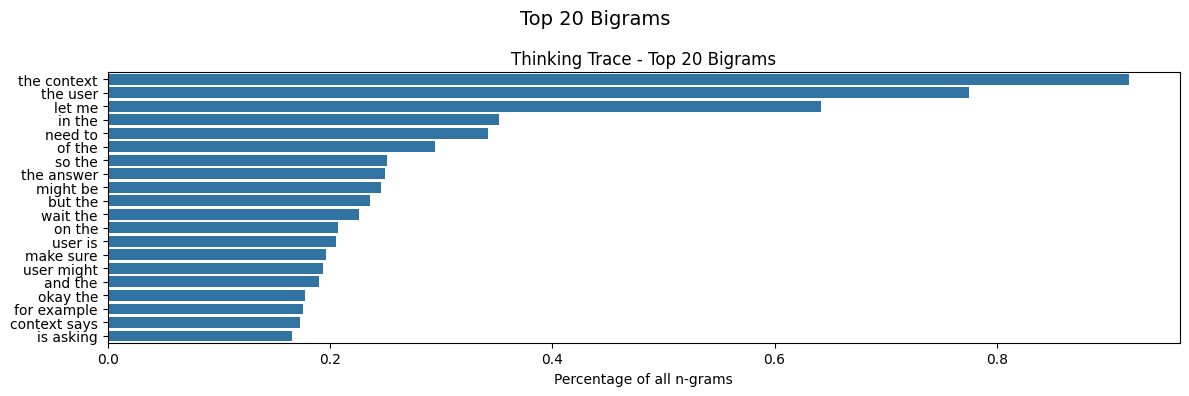

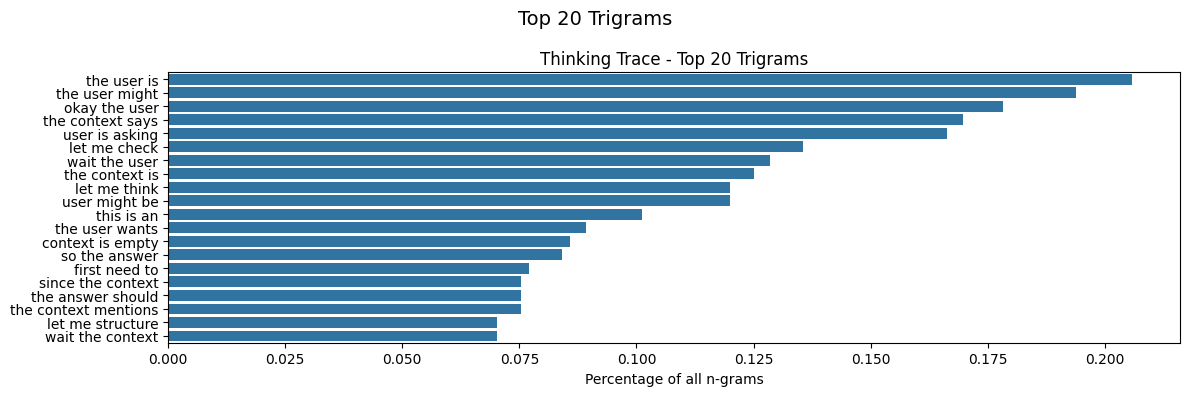

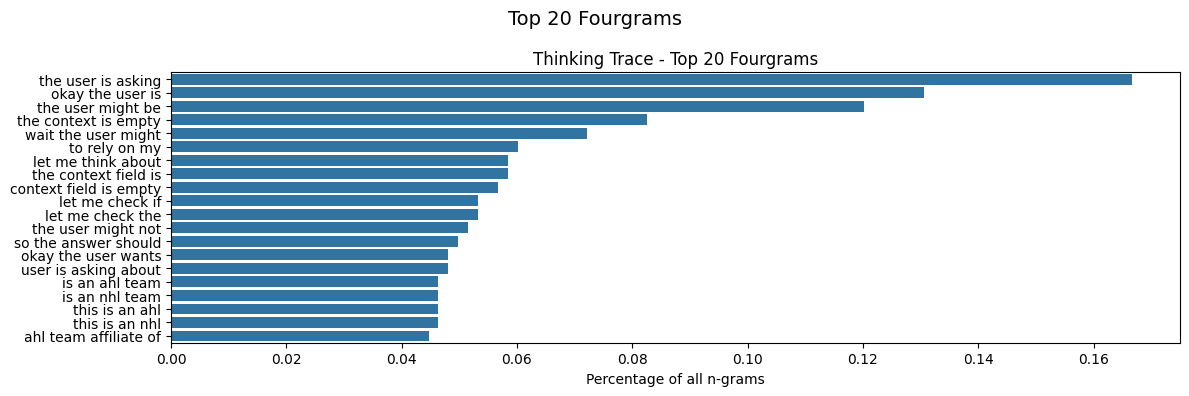

In [439]:
def plot_ngrams_separate(ngram_dict, ngram_label, top_k=20):
    """
    Plot n-grams from a dictionary of sources.
    Dynamically handles single or multiple sources.
    """
    n_items = len(ngram_dict)
    fig, axes = plt.subplots(1, n_items, figsize=(12, 4))
    
    # Handle single subplot case - wrap in list so iteration works
    if n_items == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, (source_name, ngram_list) in zip(axes, ngram_dict.items()):
        top = ngram_list[:top_k]
        temp_df = pd.DataFrame(
            top,
            columns=["ngram", "count", "percentage"]
        )
        sns.barplot(data=temp_df, x="percentage", y="ngram", ax=ax, orient="h")
        ax.set_title(f"{source_name} - Top {top_k} {ngram_label}", fontsize=12)
        ax.set_xlabel("Percentage of all n-grams")
        ax.set_ylabel("")

    plt.suptitle(f"Top {top_k} {ngram_label}", fontsize=14)
    plt.tight_layout()
    plt.show()


# Plot only thinking trace n-grams
think_bigram_dict = {
    "Thinking Trace": reasoning_think_bigrams,
}

think_trigram_dict = {
    "Thinking Trace": reasoning_think_trigrams,
}

think_fourgram_dict = {
    "Thinking Trace": reasoning_think_fourgrams,
}

plot_ngrams_separate(think_bigram_dict, "Bigrams", top_k=20)
plot_ngrams_separate(think_trigram_dict, "Trigrams", top_k=20)
plot_ngrams_separate(think_fourgram_dict, "Fourgrams", top_k=20)


## Examples with particular phrases repeated by the model

In [289]:
def get_responses_with_phrase(responses, phrase, case_sensitive=False, context_chars=0):
    """
    Print responses from a list that contain a given phrase.

    Parameters:
    - responses: iterable of strings or dicts (tries keys 'response','text','content')
    - phrase: substring to match
    - case_sensitive: bool, default False
    - context_chars: int, number of characters of context to show around the match (default 0 = print full response)
    """
    if not case_sensitive:
        phrase_cmp = phrase.lower()
    else:
        phrase_cmp = phrase

    match_count = 0
    matched_indices=[]
    matched_phrases=[]
    for idx,text in enumerate(responses):
        #print(text)
        hay = text if case_sensitive else text.lower()
        #print(hay)
        if phrase_cmp in hay:
            match_count += 1
            matched_indices.append(idx)
            # print(f"--- Match {match_count} (index {idx}) ---")
            if context_chars and context_chars > 0:
                found_at = hay.find(phrase_cmp)
                start = max(0, found_at - context_chars)
                end = min(len(text), found_at + len(phrase) + context_chars)
                #print(text[start:end])
                matched_phrases.append(text[start:end])
            else:
                print(text)
            #print()   

    # if match_count == 0:
    #     print(f"No matches found for phrase: '{phrase}'")
    return matched_indices, matched_phrases

In [302]:
inds, res=get_responses_with_phrase(list(df['instruct_responses']), "here are some", context_chars=50)
for i,r in zip(inds,res):
        print(f"Instruction:\n {df['instruction'][i]}\n")
        print(f"Instruct model Response:\n .......{r}........\n")
        print(f"Human Response:\n {str(df['response'][i])[:100]}..................\n")
        print("-----------------------------------------------------------------")

Instruction:
 What are some of the sight seeing and outdoor activities to do in Portugal, Spain

Instruct model Response:
 .......and enjoyable sightseeing and outdoor activities. Here are some top suggestions for each country:

**Portugal:**
........

Human Response:
 Day 1: Arrival in Lisbon
- Transfer from the airport to the hotel (8.6 miles/14 km)

Day 2: Lisbon
-..................

-----------------------------------------------------------------
Instruction:
 What is the best way to invest my money?

Instruct model Response:
 .......me horizon, age, and current financial situation. Here are some general guidelines to help you make informed deci........

Human Response:
 There is no one way to best invest your money, it is based on multiple factors that determines how y..................

-----------------------------------------------------------------
Instruction:
 What kind of merchant ships would be useful in a modern naval conflict?

Instruct model Response:
 .......rategic r

In [416]:
inds, res=get_responses_with_phrase(list(df['base_responses']), "based on the", context_chars=100)
for i,r in zip(inds,res):
        print(f"Instruction:\n {df['instruction'][i]}\n")
        print(f"Qwen3-4B Response:\n .......{r}........\n")
        print(f"Human Response:\n {str(df['response'][i])[:200]}.................\n")
        print("-----------------------------------------------------------------")

Instruction:
 List 10 highest-grossing actors in the world.

Qwen3-4B Response:
 .......Based on the context provided, it's important to note that creating a definitive list of the highest-grossing ac........

Human Response:
 The following are non-definitive lists of the actors with the highest career-film grosses. There are box-office gross revenue lists, which are not adjusted for inflation, as well as lists for the numb.................

-----------------------------------------------------------------
Instruction:
 Using examples taken from the text give me a summary of the main arguments in favour of slavery reparations in the United States and the anticipated cost of enacting such reparations

Qwen3-4B Response:
 .......trillion to $14.2 trillion, with an average of around $142,000 per African American. This figure is based on the economic impact of slavery and its ongoing effects, including the loss of human capital, property, ........

Human Response:
 In spite of progressive 

In [417]:
inds, res=get_responses_with_phrase(list(df['reasoning_responses']), "the provided context", context_chars=50)
for i,r in zip(inds,res):
        print(f"Instruction:\n {df['instruction'][i]}\n")
        print(f"Thinking model Response:\n .......{r}........\n")
        print(f"Human Response:\n {str(df['response'][i])[:100]}..................\n")
        print("-----------------------------------------------------------------")

Instruction:
 When was Lamb Air operating

Thinking model Response:
 .......Based on the provided context, Lamb Air Ltd. (also referred to as Lamb Airways ........

Human Response:
 Lamb Air Ltd. was a Canadian airline that began operations in 1934 in The Pas, Manitoba, and went ou..................

-----------------------------------------------------------------
Instruction:
 Tell me about Roger Federer

Thinking model Response:
 .......ort's history. Here's a concise overview based on the provided context:

### Key Achievements
- **Rankings**: Held the A........

Human Response:
 Roger Federer, born 8 August 1981, is a Swiss former professional tennis player. He was ranked world..................

-----------------------------------------------------------------
Instruction:
 What kind of publisher is the American Fantasy Press

Thinking model Response:
 .......Based on the provided context, **American Fantasy Press** is a **science fictio........

Human Response:
 American Fantasy

In [419]:
inds, res=get_responses_with_phrase(list(df['instruct_responses']), "known for its", context_chars=50)
for i,r in zip(inds,res):
        print(f"Instruction:\n {df['instruction'][i]}\n")
        print(f"Instruct model Response:\n .......{r}........\n")
        print(f"Human Response:\n {str(df['response'][i])[:100]}..................\n")
        print("-----------------------------------------------------------------")

Instruction:
 What are the top attractions to visit in Cancun?

Instruct model Response:
 .......Cancun is a popular tourist destination known for its beautiful beaches, vibrant nightlife, and rich cu........

Human Response:
 Cancun is divided into two areas. Downtown, also known as Ciudad Cancun — and Cancun Island, also kn..................

-----------------------------------------------------------------
Instruction:
 Please provide a brief summary describing Canada

Instruct model Response:
 ....... area and has the longest coastline in the world. Known for its diverse climate and geological features, Canada i........

Human Response:
 Canada is a country in North America. Its ten provinces and three territories extend from the Atlant..................

-----------------------------------------------------------------
Instruction:
 What is a good city to visit in Michigan in the summer?

Instruct model Response:
 ....... to visit in Michigan in the summer is Ann Arbor. Known for 

## N-gram overlap score using jaccard similarity

,Human,Base,Instruct,Reasoning,Thinking_Trace
Human,1.000000,0.197605,0.298701,0.234568,0.162791
Base,0.197605,1.000000,0.250000,0.169591,0.104972
Instruct,0.298701,0.250000,1.000000,0.265823,0.142857
Reasoning,0.234568,0.169591,0.265823,1.000000,0.156069
Thinking_Trace,0.162791,0.104972,0.142857,0.156069,1.000000


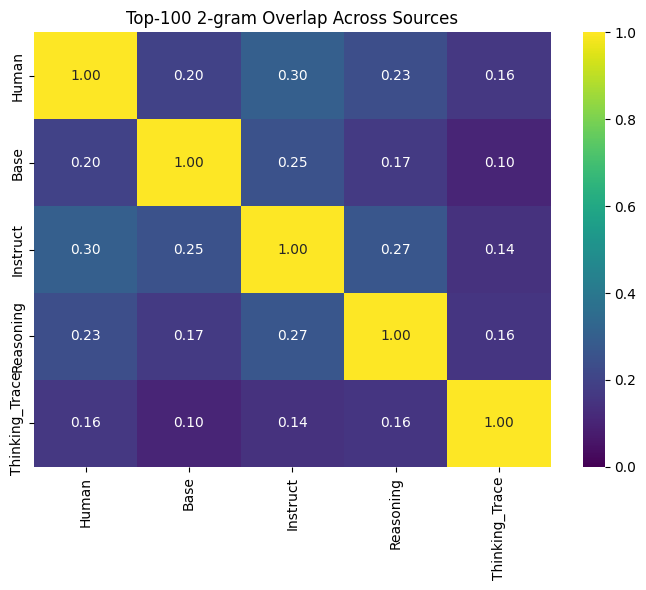

,Human,Base,Instruct,Reasoning,Thinking_Trace
Human,1.000000,0.063830,0.104972,0.036269,0.010101
Base,0.063830,1.000000,0.081081,0.041667,0.010101
Instruct,0.104972,0.081081,1.000000,0.086957,0.010101
Reasoning,0.036269,0.041667,0.086957,1.000000,0.010101
Thinking_Trace,0.010101,0.010101,0.010101,0.010101,1.000000


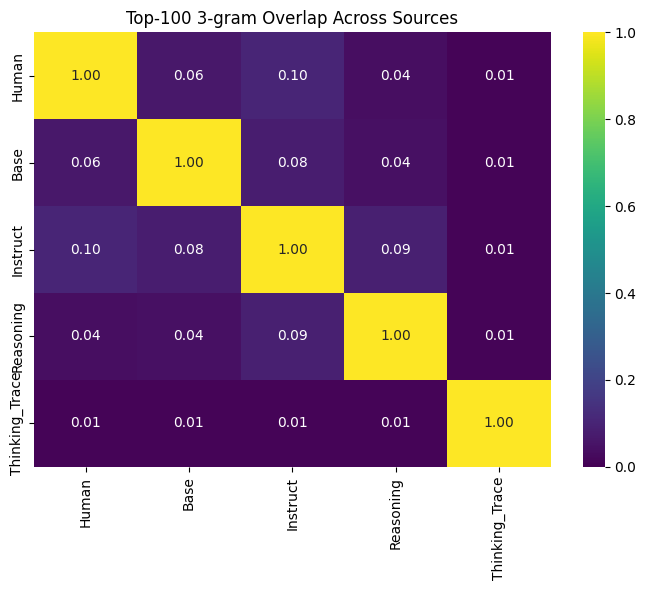

,Human,Base,Instruct,Reasoning,Thinking_Trace
Human,1.000000,0.030928,0.063830,0.030928,0.0
Base,0.030928,1.000000,0.015228,0.020408,0.0
Instruct,0.063830,0.015228,1.000000,0.063830,0.0
Reasoning,0.030928,0.020408,0.063830,1.000000,0.0
Thinking_Trace,0.000000,0.000000,0.000000,0.000000,1.0


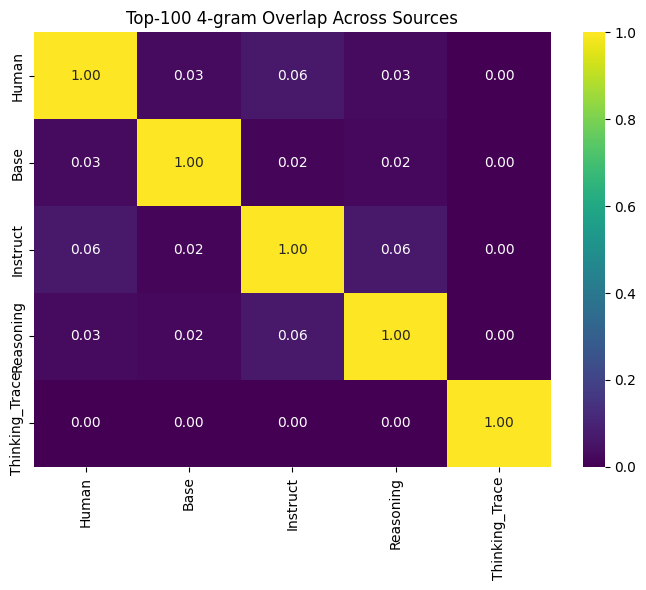

In [261]:

for n in [2, 3, 4]:
    overlap = ngram_overlap_matrix(ngram_data[n], top_k=100)
    display(overlap)
    plot_heatmap(overlap, f"Top-100 {n}-gram Overlap Across Sources")

,Human,Qwen3-4B,Instruct,Thinking
Human,1.000000,0.265823,0.290323,0.234568
Qwen3-4B,0.265823,1.000000,0.449275,0.242236
Instruct,0.290323,0.449275,1.000000,0.273885
Thinking,0.234568,0.242236,0.273885,1.000000


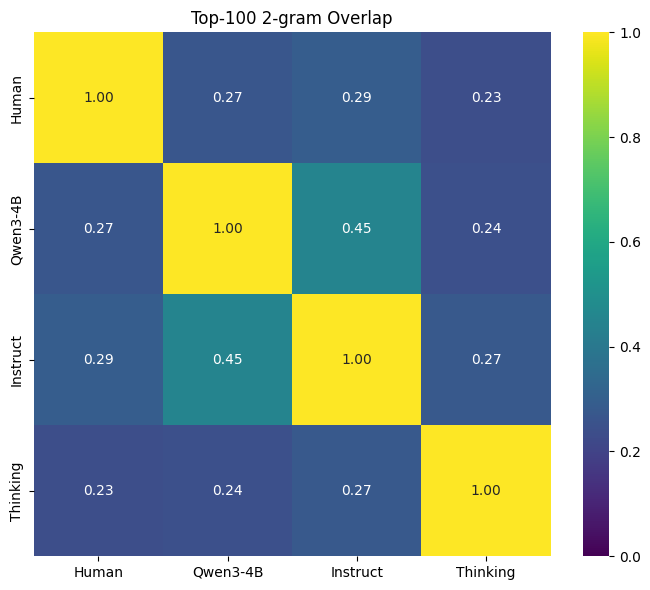

,Human,Qwen3-4B,Instruct,Thinking
Human,1.000000,0.075269,0.104972,0.036269
Qwen3-4B,0.075269,1.000000,0.111111,0.058201
Instruct,0.104972,0.111111,1.000000,0.081081
Thinking,0.036269,0.058201,0.081081,1.000000


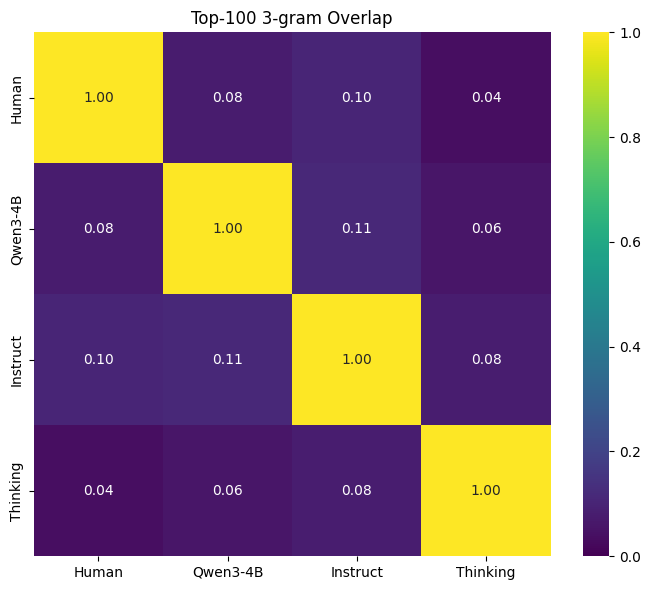

,Human,Qwen3-4B,Instruct,Thinking
Human,1.000000,0.036269,0.06383,0.030928
Qwen3-4B,0.036269,1.000000,0.06383,0.030928
Instruct,0.063830,0.063830,1.00000,0.063830
Thinking,0.030928,0.030928,0.06383,1.000000


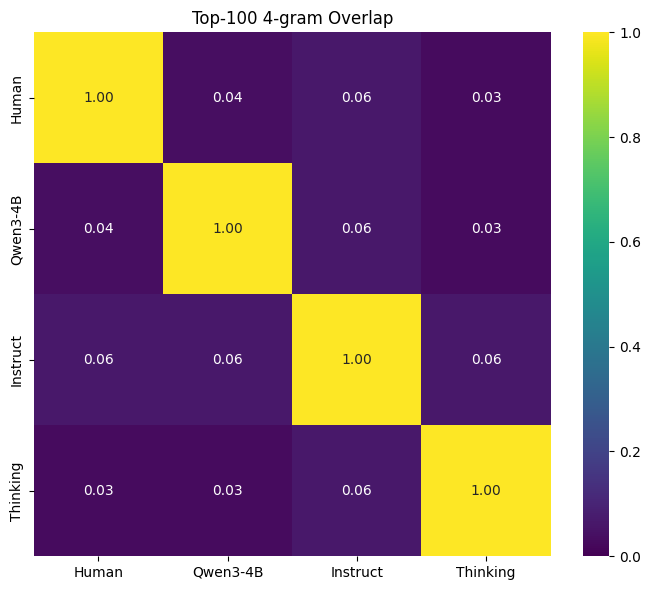

In [373]:
bigram_dict = {
    "Human": human_bigrams,
    "Qwen3-4B": base_bigrams,
    "Instruct": instruct_bigrams,
    "Thinking": reasoning_bigrams,
   # "Thinking_Trace": reasoning_think_bigrams
}

trigram_dict = {
    "Human": human_trigrams,
    "Qwen3-4B": base_trigrams,
    "Instruct": instruct_trigrams,
    "Thinking": reasoning_trigrams,
    #"Thinking_Trace": reasoning_think_trigrams
}

fourgram_dict = {
    "Human": human_fourgrams,
    "Qwen3-4B": base_fourgrams,
    "Instruct": instruct_fourgrams,
    "Thinking": reasoning_fourgrams,
    #"Thinking_Trace": reasoning_think_fourgrams
}

n_data = {
    2: bigram_dict,
    3: trigram_dict,
    4: fourgram_dict
}

for n in [2, 3, 4]:
    overlap = ngram_overlap_matrix(n_data[n], top_k=100)
    display(overlap)
    plot_heatmap(overlap, f"Top-100 {n}-gram Overlap")

## Cosine Similarity between n-gram frequencies

In [374]:
similarity_rows=[]
for n in [2, 3, 4]:
    human_ngrams = ngram_data[n]["Human"]
    for model_name in ["Base", "Instruct", "Reasoning","Thinking_Trace"]:
        sim = cosine_similarity_from_ngram_lists(
            human_ngrams,
            ngram_data[n][model_name]
        )

        similarity_rows.append({
            "n": n,
            "model": model_name,
            "cosine_similarity_to_human": sim
        })

similarity_df = pd.DataFrame(similarity_rows)
similarity_df

,n,model,cosine_similarity_to_human
0,2,Base,0.702761
1,2,Instruct,0.686747
2,2,Reasoning,0.563112
3,2,Thinking_Trace,0.346720
4,3,Base,0.146891
5,3,Instruct,0.129624
6,3,Reasoning,0.085106
7,3,Thinking_Trace,0.066348
8,4,Base,0.070306
9,4,Instruct,0.055482


,Human,Qwen3-4B,Instruct,Thinking
Human,1.000000,0.702761,0.686747,0.563112
Qwen3-4B,0.702761,1.000000,0.708537,0.559509
Instruct,0.686747,0.708537,1.000000,0.570060
Thinking,0.563112,0.559509,0.570060,1.000000


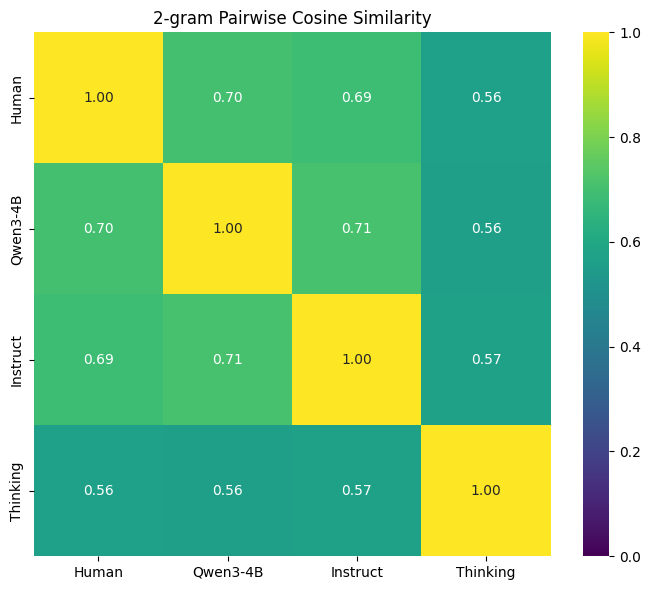

,Human,Qwen3-4B,Instruct,Thinking
Human,1.000000,0.146891,0.129624,0.085106
Qwen3-4B,0.146891,1.000000,0.241822,0.129720
Instruct,0.129624,0.241822,1.000000,0.147079
Thinking,0.085106,0.129720,0.147079,1.000000


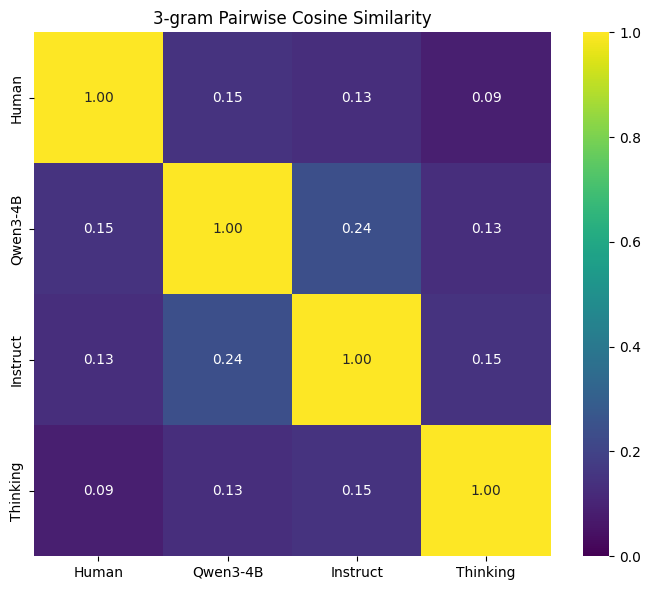

,Human,Qwen3-4B,Instruct,Thinking
Human,1.000000,0.070306,0.055482,0.032023
Qwen3-4B,0.070306,1.000000,0.140361,0.065898
Instruct,0.055482,0.140361,1.000000,0.081916
Thinking,0.032023,0.065898,0.081916,1.000000


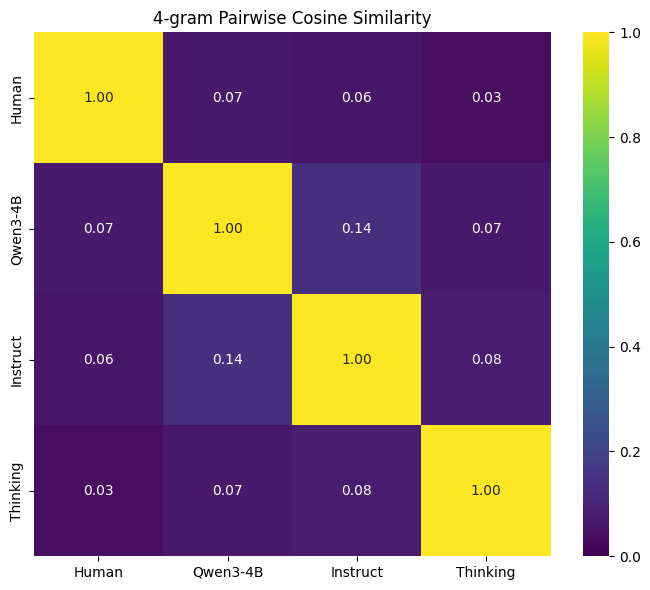

In [375]:
for n in [2, 3, 4]:
    sim_matrix = pairwise_cosine_matrix(n_data[n])
    display(sim_matrix)
    plot_heatmap(sim_matrix, f"{n}-gram Pairwise Cosine Similarity")

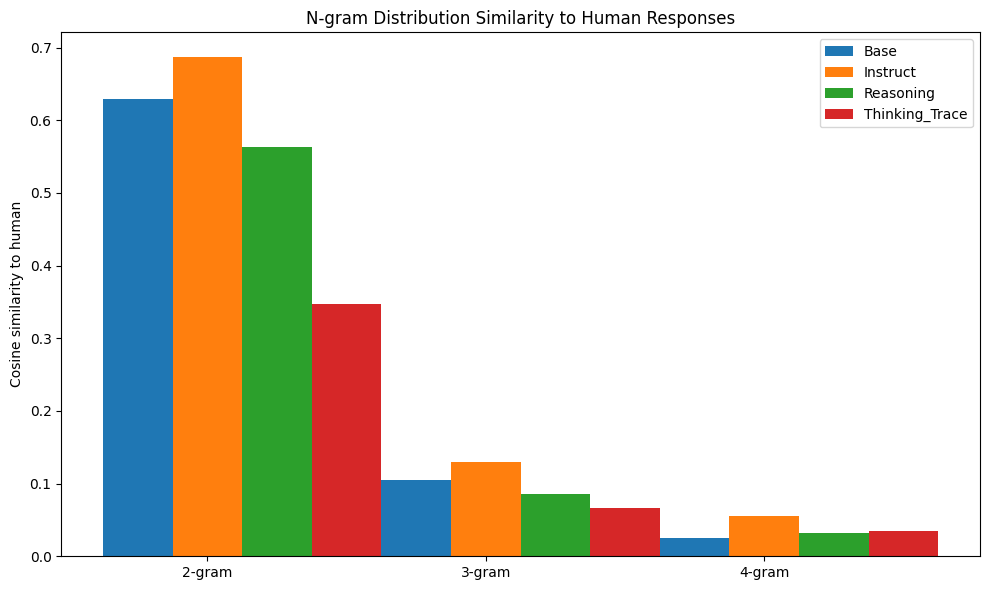

In [57]:
def plot_similarity_to_human(similarity_df):
    models = ["Base", "Instruct", "Reasoning", "Thinking_Trace"]
    n_values = [2, 3, 4]

    x = np.arange(len(n_values))
    width = 0.25

    plot_df = similarity_df.copy()
    plot_df["n"] = plot_df["n"].astype(str) + "-gram"

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=plot_df,
        x="n",
        y="cosine_similarity_to_human",
        hue="model"
    )
    plt.ylabel("Cosine similarity to human")
    plt.title("N-gram Distribution Similarity to Human Responses")
    plt.tight_layout()
    plt.show()


plot_similarity_to_human(similarity_df)

## Cosine similarity between embeddings of responses

In [393]:
model = SentenceTransformer("all-MiniLM-L6-v2")

human_texts = df["response"].tolist()
base_model_texts=df['base_responses'].tolist()
instruct_model_texts = df["instruct_responses"].tolist()
reasoning_model_texts = df["reasoning_responses"].tolist()

human_embeddings = model.encode(human_texts, convert_to_numpy=True)
instruct_model_embeddings = model.encode(instruct_model_texts, convert_to_numpy=True)
reasoning_model_embeddings = model.encode(reasoning_model_texts, convert_to_numpy=True)
base_model_embeddings=model.encode(base_model_texts, convert_to_numpy=True)

similarities = []

for h_emb, m_emb in zip(human_embeddings, base_model_embeddings):
    sim = cosine_similarity(
        h_emb.reshape(1, -1),
        m_emb.reshape(1, -1)
    )[0][0]
    similarities.append(sim)

df["semantic_similarity_base"] = similarities
similarities = []

for h_emb, m_emb in zip(human_embeddings, instruct_model_embeddings):
    sim = cosine_similarity(
        h_emb.reshape(1, -1),
        m_emb.reshape(1, -1)
    )[0][0]
    similarities.append(sim)

df["semantic_similarity_instruct"] = similarities

reasoning_similarity = [np.nan] * len(df)
valid_reasoning_indices = [
    idx for idx, text in enumerate(df["reasoning_responses"])
    if text is not None and str(text).strip() != ""
]

filtered_human_texts = [df.at[idx, "response"] for idx in valid_reasoning_indices]
filtered_reasoning_texts = [df.at[idx, "reasoning_responses"] for idx in valid_reasoning_indices]

filtered_human_embeddings = model.encode(filtered_human_texts, convert_to_numpy=True)
filtered_reasoning_embeddings = model.encode(filtered_reasoning_texts, convert_to_numpy=True)

for idx, h_emb, m_emb in zip(valid_reasoning_indices, filtered_human_embeddings, filtered_reasoning_embeddings):
    sim = cosine_similarity(
        h_emb.reshape(1, -1),
        m_emb.reshape(1, -1)
    )[0][0]
    reasoning_similarity[idx] = sim

df["semantic_similarity_reasoning"] = reasoning_similarity

In [394]:
df['semantic_similarity_instruct']

0      0.706691
1      0.442680
2      0.598229
3      0.729000
4      0.840464
         ...   
115    0.769860
116    0.719032
117    0.846287
118    0.835986
119    0.742494
Name: semantic_similarity_instruct, Length: 120, dtype: float32

In [395]:
mean_sim = df["semantic_similarity_instruct"].mean()
median_sim = df["semantic_similarity_instruct"].median()
std_sim = df["semantic_similarity_instruct"].std()

print("Mean similarity:", mean_sim)
print("Median similarity:", median_sim)
print("Std:", std_sim)

Mean similarity: 0.7418738
Median similarity: 0.77520365
Std: 0.14975877


In [396]:
mean_sim = df["semantic_similarity_reasoning"].mean()
median_sim = df["semantic_similarity_reasoning"].median()
std_sim = df["semantic_similarity_reasoning"].std()

print("Mean similarity:", mean_sim)
print("Median similarity:", median_sim)
print("Std:", std_sim)

Mean similarity: 0.734728715794031
Median similarity: 0.7641947567462921
Std: 0.14382209005717966


In [397]:
mean_sim = df["semantic_similarity_base"].mean()
median_sim = df["semantic_similarity_base"].median()
std_sim = df["semantic_similarity_base"].std()

print("Mean similarity:", mean_sim)
print("Median similarity:", median_sim)
print("Std:", std_sim)

Mean similarity: 0.7460251
Median similarity: 0.7781951
Std: 0.1349438


In [398]:
# lowest semantic similarity pairs
low_sim_base = df.sort_values("semantic_similarity_base").head(10)
low_sim_instruct = df.sort_values("semantic_similarity_instruct").head(10)
low_sim_reasoning=df.sort_values("semantic_similarity_reasoning").head(10)

# highest semantic similarity pairs
high_sim_base = df.sort_values("semantic_similarity_base", ascending=False).head(10)
high_sim_instruct = df.sort_values("semantic_similarity_instruct", ascending=False).head(10)
high_sim_reasoning = df.sort_values("semantic_similarity_reasoning", ascending=False).head(10)

In [410]:
for _, row in high_sim_base.iterrows():
    print("Similarity:", row["semantic_similarity_base"])
    print("Prompt:", row["instruction"])
    print("category:", row['category'])
    print("Human:", row["response"])
    print("base Model:", row["base_responses"])
    print("-" * 80)

Similarity: 0.9956973791122437
Prompt: Can you tell me something about Stanley J. Goldberg
category: closed_qa
Human: Stanley J. Goldberg (born Maryland, 1939) is a special trial judge of the United States Tax Court.

Goldberg attended public schools in Baltimore, MD. He earned a B.S. from the University of Maryland, School of Business and Public Administration in 1960 and an LL.B. from the University of Maryland School of Law in 1964. He did graduate work in Federal Income Taxation at New York University. Goldberg was admitted to practice in Maryland and New Jersey, 1964 and 1967, and Federal District Court. 

He began his career as a Tax Attorney in January 1965 with the United States Department of Treasury, Office of Chief Counsel, Internal Revenue Service, in New York City and was initially assigned to the General Litigation function. In 1967, he was reassigned to the Tax Litigation function. In 1976, he was promoted to Special Trial Attorney, and then to Assistant District Counsel

In [412]:
for _, row in low_sim_reasoning.iterrows():
    print("Similarity:", row["semantic_similarity_reasoning"])
    print("Prompt:", row["instruction"])
    print("category:", row['category'])
    print("Human:", row["response"])
    print("reasoning Model:", row["reasoning_responses"])
    print("-" * 80)

Similarity: 0.18001309037208557
Prompt: Who are ''The Lumières" ?
category: open_qa
Human: The Lumières (literally in English: The Lights) was a cultural, philosophical, literary and intellectual movement beginning in the second half of the 17th century, originating in western Europe and spreading throughout the rest of Europe. It included philosophers such as Baruch Spinoza, David Hume, John Locke, Edward Gibbon, Voltaire, Jean-Jacques Rousseau, Denis Diderot, Pierre Bayle and Isaac Newton. This movement is influenced by the scientific revolution in southern Europe arising directly from the Italian renaissance with people like Galileo Galilei. Over time it came to mean the Siècle des Lumières, in English the Age of Enlightenment.[Note 1]

Members of the movement saw themselves as a progressive élite, and battled against religious and political persecution, fighting against what they saw as the irrationality, arbitrariness, obscurantism and superstition of the previous centuries. They 

In [411]:
for _, row in high_sim_instruct.iterrows():
    print("Similarity:", row["semantic_similarity_instruct"])
    print("Prompt:", row["instruction"])
    print("category:", row['category'])
    print("Human:", row["response"])
    print("Instruct Model:", row["instruct_responses"])
    print("-" * 80)

Similarity: 0.9913333058357239
Prompt: Can you tell me something about Stanley J. Goldberg
category: closed_qa
Human: Stanley J. Goldberg (born Maryland, 1939) is a special trial judge of the United States Tax Court.

Goldberg attended public schools in Baltimore, MD. He earned a B.S. from the University of Maryland, School of Business and Public Administration in 1960 and an LL.B. from the University of Maryland School of Law in 1964. He did graduate work in Federal Income Taxation at New York University. Goldberg was admitted to practice in Maryland and New Jersey, 1964 and 1967, and Federal District Court. 

He began his career as a Tax Attorney in January 1965 with the United States Department of Treasury, Office of Chief Counsel, Internal Revenue Service, in New York City and was initially assigned to the General Litigation function. In 1967, he was reassigned to the Tax Litigation function. In 1976, he was promoted to Special Trial Attorney, and then to Assistant District Counsel

In [247]:
for _, row in low_sim_reasoning.iterrows():
    print("Similarity:", row["semantic_similarity_reasoning"])
    print("Prompt:", row["instruction"])
    print("Human:", row["response"])
    print("Model:", row["reasoning_responses"])
    print("-" * 80)

Similarity: 0.18001309037208557
Prompt: Who are ''The Lumières" ?
Human: The Lumières (literally in English: The Lights) was a cultural, philosophical, literary and intellectual movement beginning in the second half of the 17th century, originating in western Europe and spreading throughout the rest of Europe. It included philosophers such as Baruch Spinoza, David Hume, John Locke, Edward Gibbon, Voltaire, Jean-Jacques Rousseau, Denis Diderot, Pierre Bayle and Isaac Newton. This movement is influenced by the scientific revolution in southern Europe arising directly from the Italian renaissance with people like Galileo Galilei. Over time it came to mean the Siècle des Lumières, in English the Age of Enlightenment.[Note 1]

Members of the movement saw themselves as a progressive élite, and battled against religious and political persecution, fighting against what they saw as the irrationality, arbitrariness, obscurantism and superstition of the previous centuries. They redefined the stud

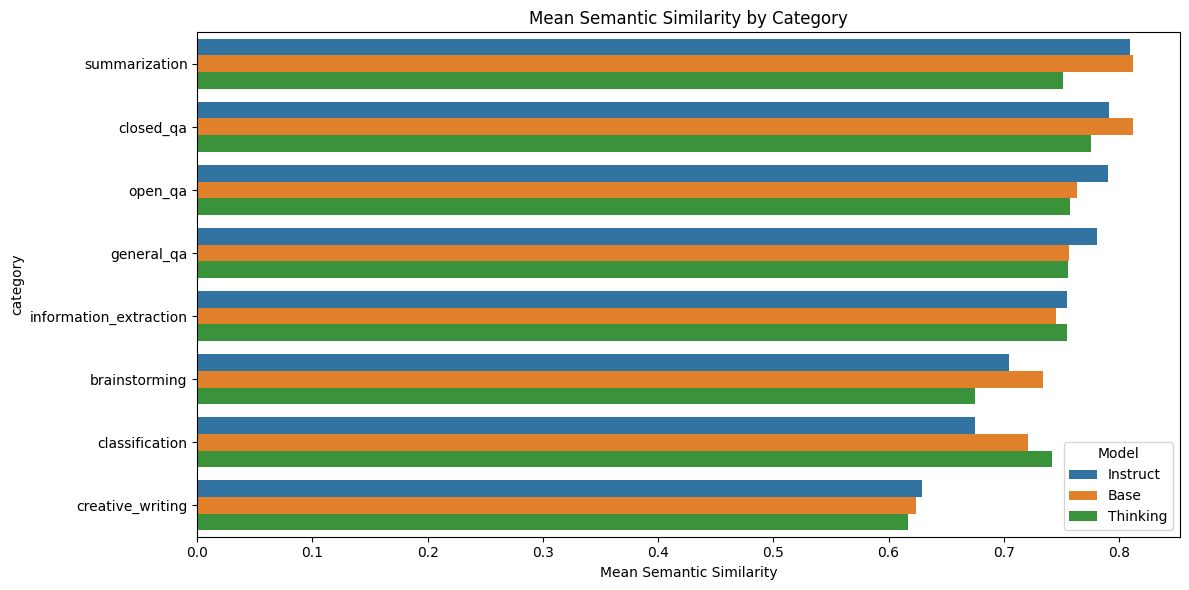

In [407]:
category_similarity_instruct = df.groupby('category')['semantic_similarity_instruct'].mean()
category_similarity_base = df.groupby('category')['semantic_similarity_base'].mean()
category_similarity_reasoning = df.groupby('category')['semantic_similarity_reasoning'].mean()

# Combine into a single dataframe
combined_similarity = pd.DataFrame({
    'Instruct': category_similarity_instruct,
    'Base': category_similarity_base,
    'Thinking':category_similarity_reasoning
})

# Sort by base model values
combined_similarity = combined_similarity.sort_values('Base', ascending=False)

# Reshape for plotting
plot_data = combined_similarity.reset_index()
plot_data = plot_data.melt(id_vars='category', var_name='Model', value_name='Mean Semantic Similarity')

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_data, x='Mean Semantic Similarity', y='category', hue='Model', orient='h')
plt.xlabel('Mean Semantic Similarity')
plt.title('Mean Semantic Similarity by Category')
plt.tight_layout()
plt.show()


In [37]:
def ngram_diversity(ngram_list):
    df_temp = ngram_list_to_df(ngram_list)

    unique_ngrams = len(df_temp)
    total_ngrams = df_temp["count"].sum()

    if total_ngrams == 0:
        return 0

    return unique_ngrams / total_ngrams

In [38]:
diversity_rows = []

for n in [2, 3, 4]:
    for source_name, ngram_list in ngram_data[n].items():
        diversity_rows.append({
            "n": n,
            "source": source_name,
            "diversity": ngram_diversity(ngram_list)
        })

diversity_df = pd.DataFrame(diversity_rows)
diversity_df

,n,source,diversity
0,2,Human,0.751815
1,2,Base,0.757137
2,2,Instruct,0.809599
3,2,Reasoning,0.851059
4,2,Thinking_Trace,0.514587
5,3,Human,0.947802
6,3,Base,0.929961
7,3,Instruct,0.958303
8,3,Reasoning,0.969310
9,3,Thinking_Trace,0.756906


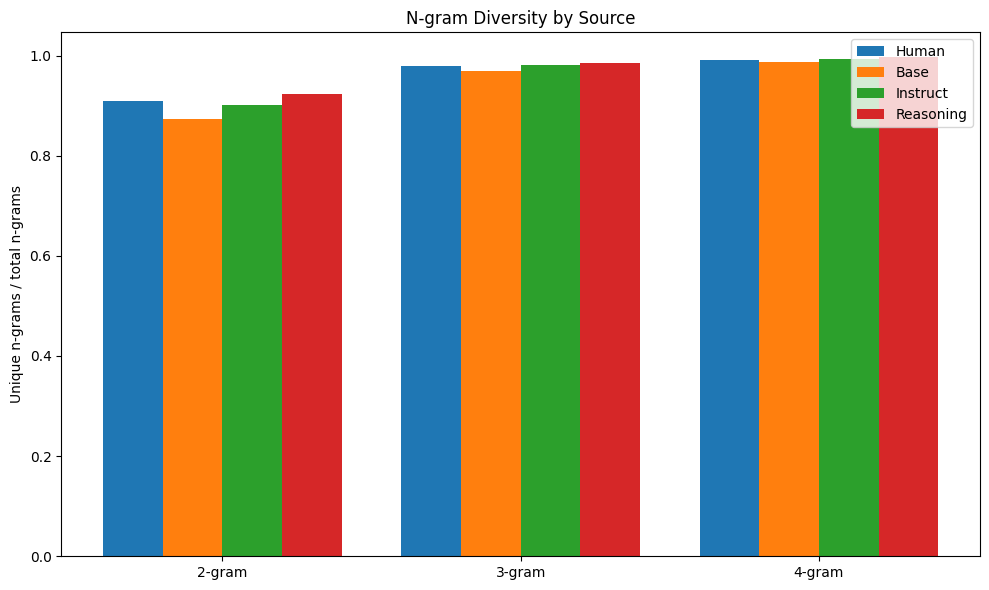

In [ ]:
def plot_ngram_diversity(diversity_df):
    sources = ["Human", "Base", "Instruct", "Reasoning"]
    n_values = [2, 3, 4]

    x = np.arange(len(n_values))
    width = 0.2

    plot_df = diversity_df.copy()
    plot_df["n"] = plot_df["n"].astype(str) + "-gram"

    plt.figure(figsize=(10, 6))
    sns.barplot(data=plot_df, x="n", y="diversity", hue="source")
    plt.ylabel("Unique n-grams / total n-grams")
    plt.title("N-gram Diversity by Source")
    plt.tight_layout()
    plt.show()


plot_ngram_diversity(diversity_df)